In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from csbdeep.utils import axes_dict, plot_some, plot_history
from csbdeep.utils.tf import limit_gpu_memory
from csbdeep.io import load_training_data
from csbdeep.models import Config, CARE

I0000 00:00:1778690261.670705    7762 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778690261.978547    7762 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778690263.403479    7762 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(X,Y), (X_val,Y_val), axes = load_training_data('./data_simulated/training_sim_Z_noisy_20260513.npz', validation_split=0.1, verbose=True)   #w permuted

c = axes_dict(axes)['C'] 
n_channel_in, n_channel_out = X.shape[c], Y.shape[c]

number of training images:	 33345
number of validation images:	 3705
image size (3D):		 (96, 32, 32)
axes:				 SZYXC
channels in / out:		 1 / 1


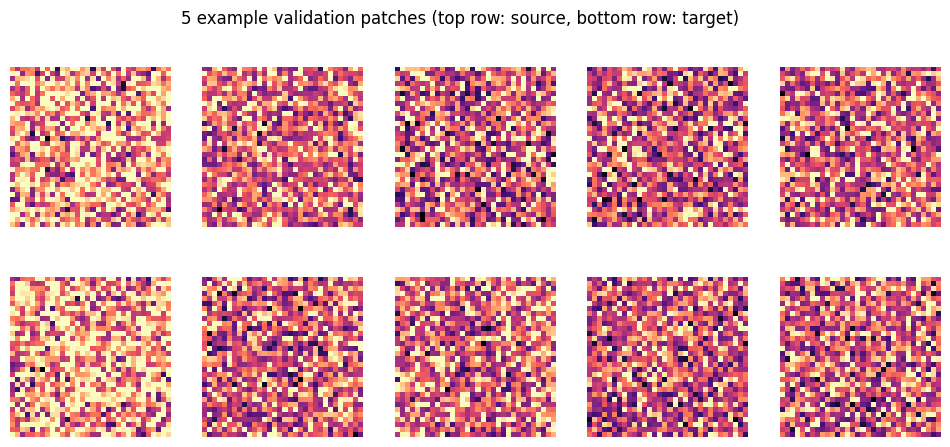

In [3]:
plt.figure(figsize=(12,5))
plot_some(X_val[:5],Y_val[:5])
plt.suptitle('5 example validation patches (top row: source, bottom row: target)');

In [4]:
config = Config(
    axes= axes,                # 3D with channel-last
    n_channel_in=1,
    n_channel_out=1,
    probabilistic=False,
    unet_residual=True,
    unet_n_depth=4,
    unet_kern_size=3,
    unet_n_first=32,
    train_epochs=100,
    train_steps_per_epoch=100,
)
print(config)
vars(config)

Config(n_dim=3, axes='ZYXC', n_channel_in=1, n_channel_out=1, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', probabilistic=False, unet_residual=True, unet_n_depth=4, unet_kern_size=3, unet_n_first=32, unet_last_activation='linear', unet_input_shape=(None, None, None, 1), train_loss='mae', train_epochs=100, train_steps_per_epoch=100, train_learning_rate=0.0004, train_batch_size=16, train_tensorboard=True, train_reduce_lr={'factor': 0.5, 'patience': 10, 'min_delta': 0})


{'n_dim': 3,
 'axes': 'ZYXC',
 'n_channel_in': 1,
 'n_channel_out': 1,
 'train_checkpoint': 'weights_best.h5',
 'train_checkpoint_last': 'weights_last.h5',
 'train_checkpoint_epoch': 'weights_now.h5',
 'probabilistic': False,
 'unet_residual': True,
 'unet_n_depth': 4,
 'unet_kern_size': 3,
 'unet_n_first': 32,
 'unet_last_activation': 'linear',
 'unet_input_shape': (None, None, None, 1),
 'train_loss': 'mae',
 'train_epochs': 100,
 'train_steps_per_epoch': 100,
 'train_learning_rate': 0.0004,
 'train_batch_size': 16,
 'train_tensorboard': True,
 'train_reduce_lr': {'factor': 0.5, 'patience': 10, 'min_delta': 0}}

In [5]:
model = CARE(config, 'wpermute_model_4layers_20260513', basedir='models')

W0000 00:00:1778690350.603354    7762 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778690350.603496    7762 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778690350.874263    7762 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778690350.874305    7762 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778690350.883851    7762 gpu_device.cc:2040] Create

In [6]:
history = model.train(X,Y, validation_data=(X_val,Y_val))

Epoch 1/100


I0000 00:00:1778690357.646144    8697 service.cc:158] XLA service 0x7f2ca00092a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778690357.646173    8697 service.cc:166]   StreamExecutor device (0): NVIDIA GeForce RTX 5090, Compute Capability 12.0a
I0000 00:00:1778690357.646178    8697 service.cc:166]   StreamExecutor device (1): NVIDIA GeForce RTX 5090, Compute Capability 12.0a
I0000 00:00:1778690357.758299    8697 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778690358.239279    8697 cuda_dnn.cc:463] Loaded cuDNN version 91002


  1/100 ━━━━━━━━━━━━━━━━━━━━ 22:37 14s/step - loss: 0.2005 - mae: 0.2005 - mse: 0.0632

I0000 00:00:1778690367.337197    8697 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.1681 - mae: 0.1681 - mse: 0.0452

/opt/venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=('Tensor(shape=(1, 96, 32, 32, 1))',)
  warnings.warn(msg)


100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 264ms/step - loss: 0.1537 - mae: 0.1537 - mse: 0.0375 - val_loss: 0.1445 - val_mae: 0.1445 - val_mse: 0.0327 - learning_rate: 4.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.1431 - mae: 0.1431 - mse: 0.0321 - val_loss: 0.1423 - val_mae: 0.1423 - val_mse: 0.0317 - learning_rate: 4.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.1422 - mae: 0.1422 - mse: 0.0317 - val_loss: 0.1421 - val_mae: 0.1421 - val_mse: 0.0316 - learning_rate: 4.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.1420 - mae: 0.1420 - mse: 0.0316 - val_loss: 0.1419 - val_mae: 0.1419 - val_mse: 0.0316 - learning_rate: 4.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.1419 - mae: 0.1419 - mse: 0.0315 - val_loss: 0.1418 - val_mae: 0.1418 - val_mse: 0.0315 - learning_rate: 4.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.1418 - mae: 0.1418 - mse: 0.0315 - v

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


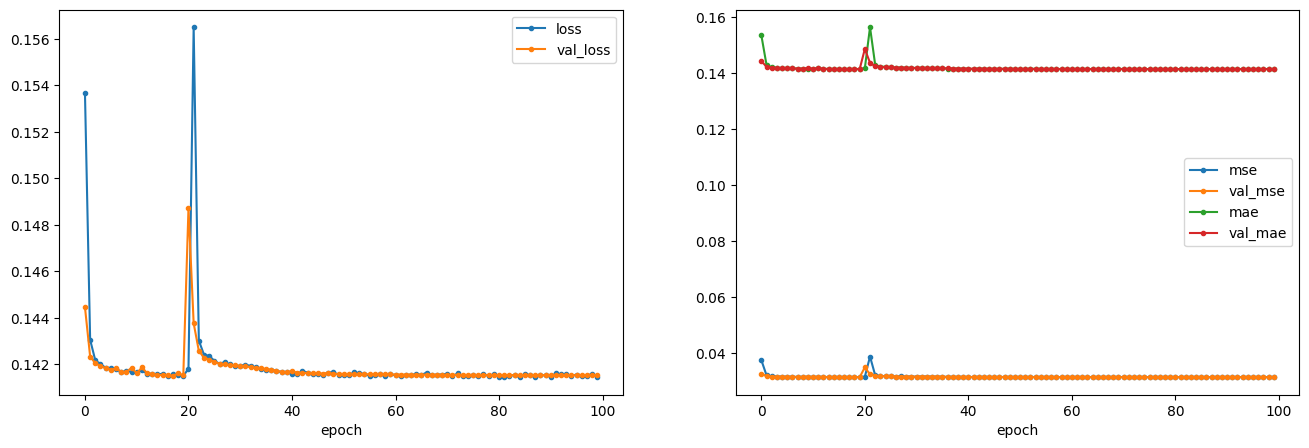

In [7]:
print(sorted(list(history.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [9]:
import tensorflow as tf
opt = model.keras_model.optimizer

# Works in TF2.x
try:
    opt.learning_rate.assign(2e-4)
except AttributeError:
    # Older TF/Keras uses .lr
    tf.keras.backend.set_value(opt.lr, 2e-4)

history2 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - loss: 0.1484 - mae: 0.1484 - mse: 0.0346 - val_loss: 0.1428 - val_mae: 0.1428 - val_mse: 0.0320 - learning_rate: 2.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.1425 - mae: 0.1425 - mse: 0.0318 - val_loss: 0.1422 - val_mae: 0.1422 - val_mse: 0.0317 - learning_rate: 2.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 0.1422 - mae: 0.1422 - mse: 0.0317 - val_loss: 0.1421 - val_mae: 0.1421 - val_mse: 0.0316 - learning_rate: 2.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.1421 - mae: 0.1421 - mse: 0.0316 - val_loss: 0.1420 - val_mae: 0.1420 - val_mse: 0.0316 - learning_rate: 2.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.1419 - mae: 0.1419 - mse: 0.0316 - val_loss: 0.1421 - val_mae: 0.1421 - val_mse: 0.0317 - learning_rate: 2.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.1419 - mae: 0.1419 - mse

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


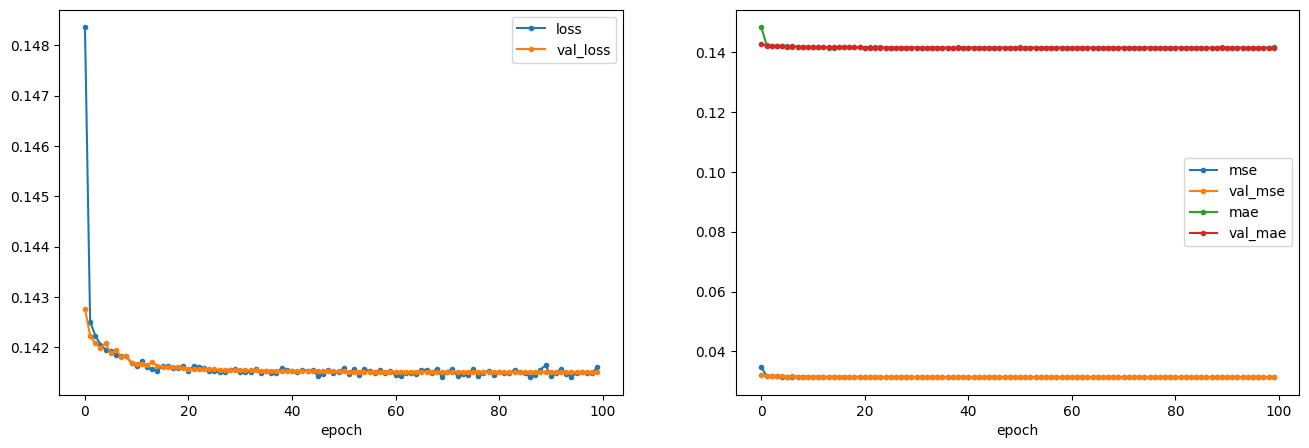

In [10]:
print(sorted(list(history2.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history2,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [12]:
history3 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0453 - mae: 0.0453 - mse: 0.0040 - val_loss: 0.0452 - val_mae: 0.0452 - val_mse: 0.0040 - learning_rate: 2.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0455 - mae: 0.0455 - mse: 0.0040 - val_loss: 0.0452 - val_mae: 0.0452 - val_mse: 0.0040 - learning_rate: 2.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0451 - mae: 0.0451 - mse: 0.0039 - val_loss: 0.0452 - val_mae: 0.0452 - val_mse: 0.0040 - learning_rate: 2.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0448 - mae: 0.0448 - mse: 0.0039 - val_loss: 0.0450 - val_mae: 0.0450 - val_mse: 0.0040 - learning_rate: 2.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0458 - mae: 0.0458 - mse: 0.0041 - val_loss: 0.0453 - val_mae: 0.0453 - val_mse: 0.0040 - learning_rate: 2.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0459 - mae: 0.0459 - mse: 0.0041 -

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


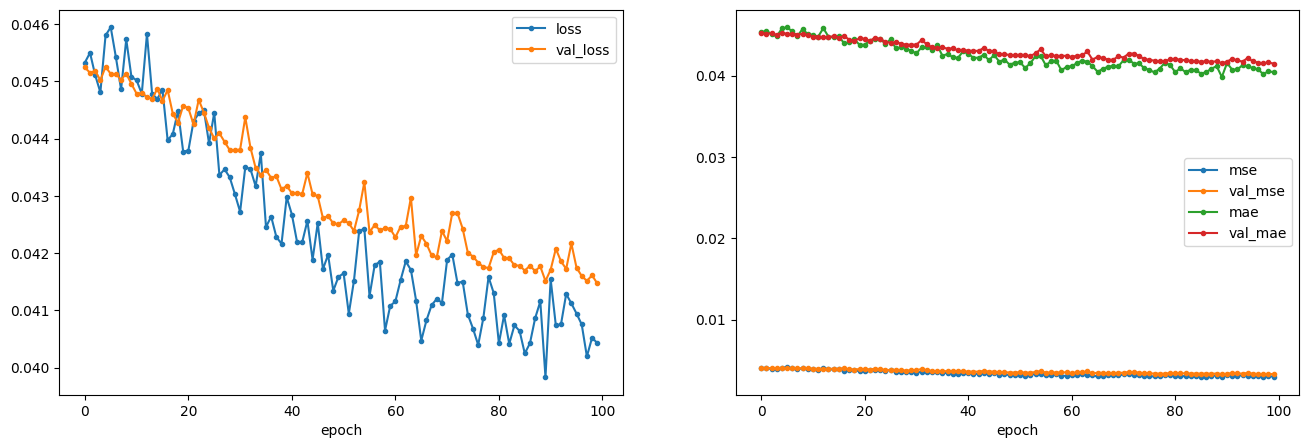

In [14]:
print(sorted(list(history3.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history3,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [16]:
import tensorflow as tf
opt = model.keras_model.optimizer

# Works in TF2.x
try:
    opt.learning_rate.assign(1e-4)
except AttributeError:
    # Older TF/Keras uses .lr
    tf.keras.backend.set_value(opt.lr, 1e-4)
history4 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0414 - val_mae: 0.0414 - val_mse: 0.0033 - learning_rate: 1.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0402 - mae: 0.0402 - mse: 0.0030 - val_loss: 0.0413 - val_mae: 0.0413 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0414 - val_mae: 0.0414 - val_mse: 0.0033 - learning_rate: 1.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0413 - val_mae: 0.0413 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0402 - mae: 0.0402 - mse: 0.0030 - val_loss: 0.0412 - val_mae: 0.0412 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0401 - mae: 0.0401 - mse: 0.0029 - v

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


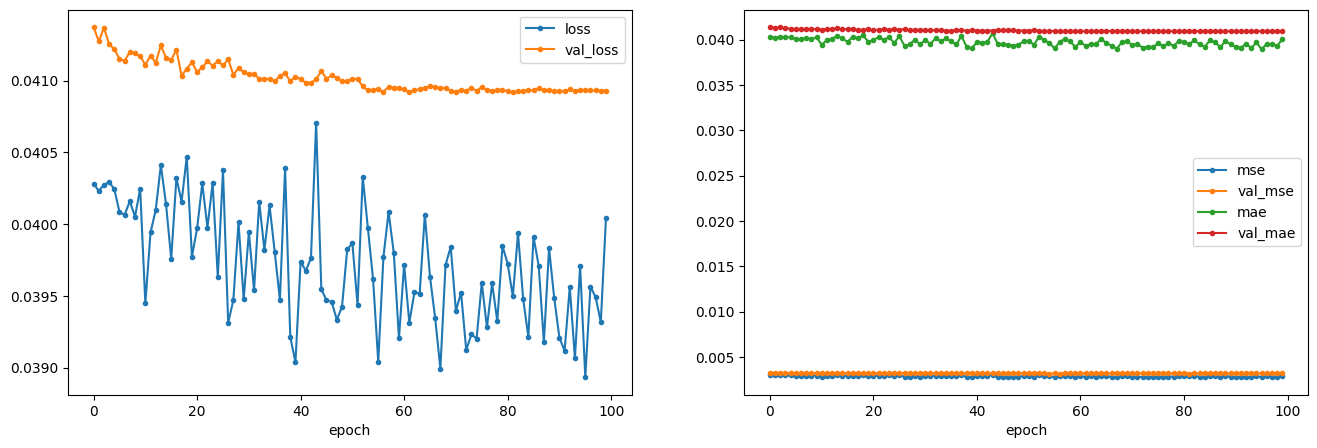

In [18]:
print(sorted(list(history4.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history4,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


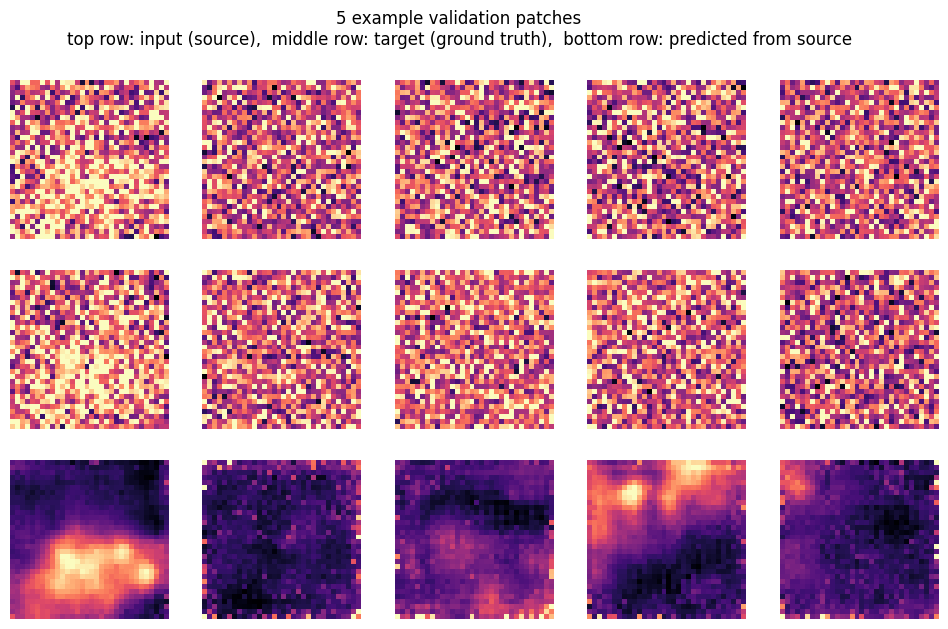

In [13]:
plt.figure(figsize=(12,7))
_P = model.keras_model.predict(X_val[5:10])
if config.probabilistic:
    _P = _P[...,:(_P.shape[-1]//2)]
plot_some(X_val[5:10],Y_val[5:10],_P,pmax=99.5)
plt.suptitle('5 example validation patches\n'      
             'top row: input (source),  '          
             'middle row: target (ground truth),  '
             'bottom row: predicted from source');

In [11]:
print(_P.shape)

(5, 32, 96, 96, 1)
